In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from helpers import ( prep_the_data, 
                      export_puma_kepler, 
                      add_typical_week_date_from_dow_complaint,
                      build_typical_week_counts, 
                      build_typical_week_city_relative_ratio,
                      make_daily_table_for_model_with_puma,
                      make_topn_table,
                      plot_topn_shrinkage_vs_raw,
                      plot_topn_absdiff,
                      export_idata
                    )


import geopandas as gpd
from keplergl import KeplerGl

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2022__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2022-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31") &
     (df_puma["time_of_day"] ==  "night")
].copy()


In [6]:
df_puma_2022__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
3,4103,Noise,"Noise, Barking Dog",NaN,2022-08-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Tuesday,August,0,August__2022,Animal,ANIMAL__Tuesday
5,4103,Noise,"Noise, Barking Dog",NaN,2022-08-22,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,August,0,August__2022,Animal,ANIMAL__Monday
6,4103,Noise,"Noise, Barking Dog",NaN,2022-08-27,night,1,MN0301,0.245574,Chinatown-Two Bridges,Saturday,August,1,August__2022,Animal,ANIMAL__Saturday
8,4103,Noise,"Noise, Barking Dog",NaN,2023-06-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Friday,June,0,June__2023,Animal,ANIMAL__Friday
10,4103,Noise,"Noise, Barking Dog",NaN,2023-06-12,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,June,0,June__2023,Animal,ANIMAL__Monday


In [7]:
typical = build_typical_week_counts(df_puma_2022__2024)

In [8]:
typical = add_typical_week_date_from_dow_complaint(typical)

In [9]:
out_path="../data/processed/kepler"

gdf_typical_week = export_puma_kepler(
    typical,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    value_cols=["typical_daily_count"],
    fill_value=0,
   out_path =f"{out_path}/puma_typical_week_observed_counts.geojson" ,
)


In [10]:
city_rel_ratio_raw = build_typical_week_city_relative_ratio(
    df_puma_2022__2024,
    agg="median",
)

In [11]:
city_rel_ratio_raw.head()

,puma,complaint,dow,typical_daily_count,city_weekday_mean,city_relative_ratio,date
0,4103,Animal,Friday,1.0,1.033333,0.967742,2000-01-07
1,4103,Animal,Monday,1.0,1.051020,0.951456,2000-01-03
2,4103,Animal,Saturday,1.0,1.030612,0.970297,2000-01-08
3,4103,Animal,Sunday,1.0,1.009434,0.990654,2000-01-09
4,4103,Animal,Tuesday,1.0,1.032609,0.968421,2000-01-04


In [12]:
gdf_rel = export_puma_kepler(
    city_rel_ratio_raw,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    value_cols=["city_relative_ratio"],
    fill_value=0.0,
    out_path=f"{out_path}/puma_typical_week_city_relative_intensity.geojson",
)


In [13]:
daily_df, coords = make_daily_table_for_model_with_puma(
    df_puma_2022__2024,
    complaint_col="descriptor_group",
)

In [14]:
# -----------------------------
# Data for the model
# -----------------------------
y = daily_df["daily_count"].to_numpy(dtype=int)
puma_idx = daily_df["puma_idx"].to_numpy(dtype=int)
dow_idx = daily_df["dow_idx"].to_numpy(dtype=int)


In [15]:
# PUMA labels
# puma_labels = np.sort(daily_df["puma"].unique())

# # Fixed weekday order (important!)
# dow_labels = np.array([
#     "Monday", "Tuesday", "Wednesday",
#     "Thursday", "Friday", "Saturday", "Sunday"
# ])

# coords = {
#     "puma": puma_labels,
#     "dow": dow_labels,
# }

In [16]:
# -----------
# Model: 
# -----------------------------
with pm.Model(coords=coords) as model_pois:

    # Expected daily complaints per (PUMA, weekday)
    lam = pm.Exponential("lam", 1.0, dims=("puma", "dow"))

    # Likelihood
    y_obs = pm.Poisson("y_obs", mu=lam[puma_idx, dow_idx], observed=y)

    # Sampling
    idata_pois = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.


In [17]:
az.summary(idata_pois)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"lam[4103, Monday]",16.614,0.700,15.323,17.934,0.007,0.014,10322.0,2778.0,1.00
"lam[4103, Tuesday]",17.203,0.704,15.969,18.581,0.007,0.018,9145.0,2163.0,1.01
"lam[4103, Wednesday]",19.112,0.723,17.765,20.484,0.007,0.013,9502.0,2633.0,1.00
"lam[4103, Thursday]",25.001,0.853,23.311,26.513,0.009,0.016,9026.0,2700.0,1.00
"lam[4103, Friday]",31.676,0.917,30.008,33.442,0.009,0.017,10366.0,2748.0,1.00
...,...,...,...,...,...,...,...,...,...
"lam[4503, Wednesday]",5.032,0.381,4.347,5.771,0.004,0.007,9536.0,2721.0,1.00
"lam[4503, Thursday]",5.328,0.397,4.579,6.051,0.004,0.007,7701.0,2981.0,1.00
"lam[4503, Friday]",8.578,0.485,7.656,9.463,0.005,0.010,9881.0,2181.0,1.00
"lam[4503, Saturday]",17.917,0.714,16.604,19.247,0.008,0.013,8421.0,2621.0,1.00


In [18]:


# Posterior draws of lam[puma, dow]
lam_post = idata_pois.posterior["lam"]  # dims: chain, draw, puma, dow

# Posterior mean
lam_mean = (
    lam_post.mean(dim=("chain", "draw"))
    .to_dataframe(name="lam_mean")
    .reset_index()
)

# 90% HDI (az.hdi returns a Dataset)
hdi_ds = az.hdi(lam_post, hdi_prob=0.9)
hdi_da = hdi_ds["lam"]  # DataArray with dim "hdi" (lower/higher)

lam_hdi = (
    hdi_da.to_dataframe(name="lam_hdi")
    .reset_index()
    .pivot_table(index=["puma", "dow"], columns="hdi", values="lam_hdi")
    .reset_index()
    .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
)

# Merge mean + interval
df_post = lam_mean.merge(lam_hdi, on=["puma", "dow"], how="left")
df_post["lam_width_90"] = df_post["lam_high_90"] - df_post["lam_low_90"]

# Synthetic week date for Kepler animation
dow_to_date = {
    "Monday":    "2000-01-03",
    "Tuesday":   "2000-01-04",
    "Wednesday": "2000-01-05",
    "Thursday":  "2000-01-06",
    "Friday":    "2000-01-07",
    "Saturday":  "2000-01-08",
    "Sunday":    "2000-01-09",
}



In [19]:
df_post["date"] = pd.to_datetime(df_post["dow"].map(dow_to_date), errors="coerce").astype("datetime64[ns]")

df_post.head()

,puma,dow,lam_mean,lam_high_90,lam_low_90,lam_width_90,date
0,4103,Monday,16.614396,17.757426,15.457776,2.299650,2000-01-03
1,4103,Tuesday,17.203313,18.302066,16.022990,2.279076,2000-01-04
2,4103,Wednesday,19.111900,20.283663,17.908559,2.375104,2000-01-05
3,4103,Thursday,25.001159,26.428980,23.624045,2.804936,2000-01-06
4,4103,Friday,31.675541,33.117984,30.128427,2.989557,2000-01-07


In [20]:
# city baseline: mean across PUMAs for each weekday
city = (
    df_post.groupby("dow", as_index=False)["lam_mean"]
          .mean()
          .rename(columns={"lam_mean": "city_lam_mean"})
)

df_post = df_post.merge(city, on="dow", how="left")
df_post["city_relative_ratio"] = df_post["lam_mean"] / df_post["city_lam_mean"]

df_post.head()


,puma,dow,lam_mean,lam_high_90,lam_low_90,lam_width_90,date,city_lam_mean,city_relative_ratio
0,4103,Monday,16.614396,17.757426,15.457776,2.299650,2000-01-03,14.683018,1.131538
1,4103,Tuesday,17.203313,18.302066,16.022990,2.279076,2000-01-04,13.188420,1.304426
2,4103,Wednesday,19.111900,20.283663,17.908559,2.375104,2000-01-05,12.570521,1.520375
3,4103,Thursday,25.001159,26.428980,23.624045,2.804936,2000-01-06,14.259426,1.753308
4,4103,Friday,31.675541,33.117984,30.128427,2.989557,2000-01-07,20.147012,1.572220


In [21]:
gdf_rel = export_puma_kepler(
    df_post,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    value_cols=["city_relative_ratio"],
    fill_value=0.0,
    out_path=f"{out_path}/puma_typical_week_city_post_relative_intensity.geojson",
)


In [22]:
cmp = df_post.merge(city_rel_ratio_raw, on=["puma", "dow"], how="left")

cmp["abs_diff"] = cmp["lam_mean"] - cmp["city_weekday_mean"]
cmp["rel_diff_pct"] = 100.0 * cmp["abs_diff"] / (cmp["city_weekday_mean"].replace(0, np.nan))

cmp[["puma","dow","lam_mean","city_weekday_mean","abs_diff","rel_diff_pct","lam_width_90"]].head()


,puma,dow,lam_mean,city_weekday_mean,abs_diff,rel_diff_pct,lam_width_90
0,4103,Monday,16.614396,1.051020,15.563375,1480.787146,2.29965
1,4103,Monday,16.614396,1.194444,15.419951,1290.972648,2.29965
2,4103,Monday,16.614396,2.336364,14.278032,611.121987,2.29965
3,4103,Monday,16.614396,3.000000,13.614396,453.813184,2.29965
4,4103,Monday,16.614396,10.072727,6.541668,64.944360,2.29965


In [23]:
print("Correlation (posterior vs raw):",
      cmp[["lam_mean","city_weekday_mean"]].corr().iloc[0,1])



Correlation (posterior vs raw): 0.15872008724253814


In [24]:

top = make_topn_table(
    cmp,
    sort_by="abs_diff",     # or "city_weekday_mean" depending on intent
    ascending=False,
    n=10,
    cols=["puma", "dow", "lam_mean", "city_weekday_mean"],
)

# Compute signed change
top["delta"] = top["lam_mean"] - top["city_weekday_mean"]

# Summary statistic
print(
    "Median absolute change:",
    np.median(np.abs(top["delta"]))
)

Median absolute change: 114.38947821823646


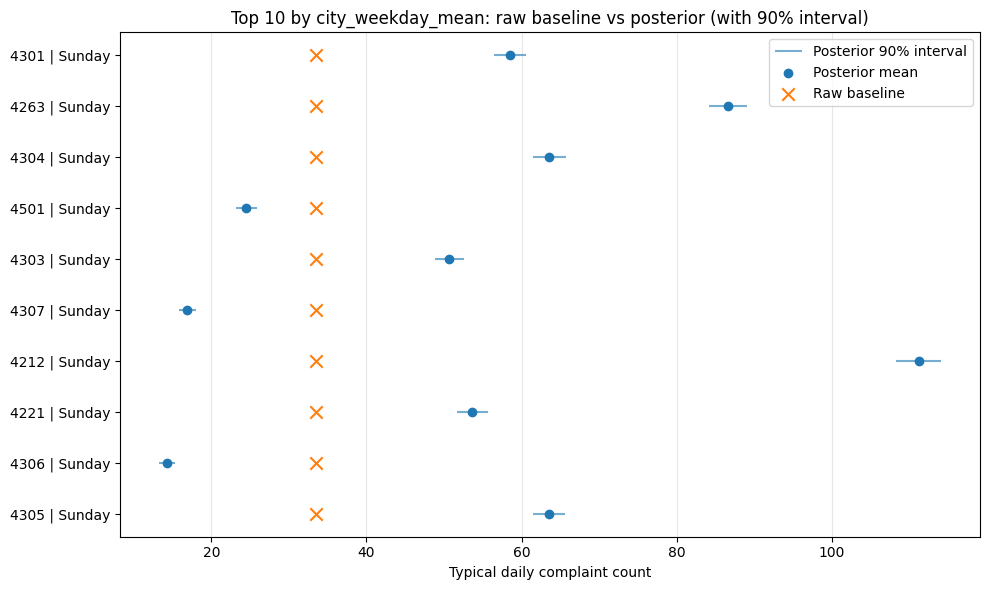

In [25]:
# Plot 1: “largest raw baselines” (your earlier table)
_ = plot_topn_shrinkage_vs_raw(cmp, n=10)

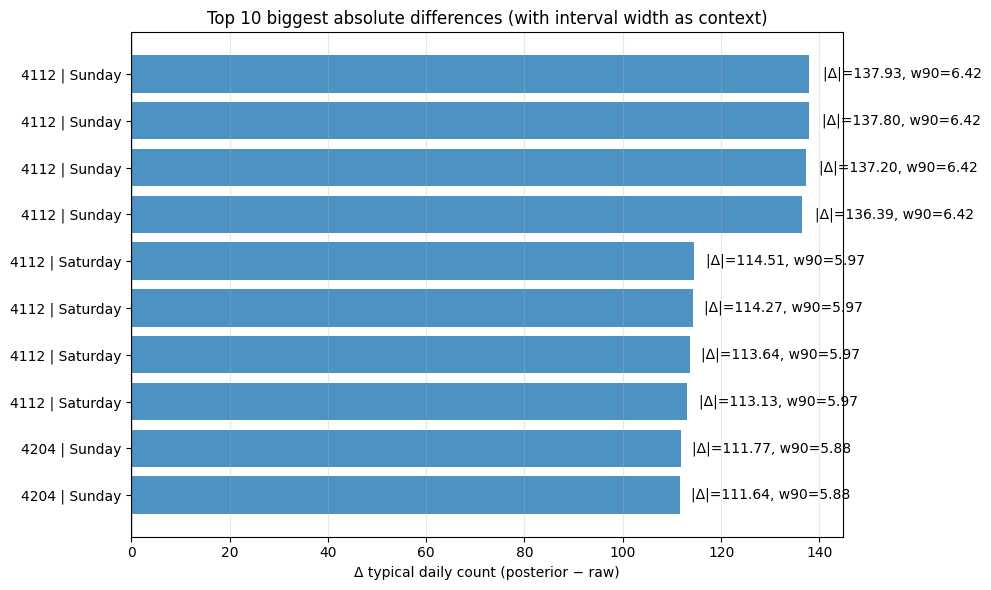

In [26]:
# This focuses directly on how much the model changed things.
# Interpretation

# Bars < 0 → posterior pulled down noisy raw estimates

# Bars > 0 → posterior corrected underestimates

# Most large raw values should move toward zero (classic shrinkage)

_= plot_topn_absdiff(cmp, n=10)

In [27]:
export_idata(idata_pois, "../data/processed/models/model2_pois_idata.nc")

✅ Saved idata -> ../data/processed/models/model2_pois_idata.nc


'../data/processed/models/model2_pois_idata.nc'